<a href="https://colab.research.google.com/github/bingjunw/dj-scratch/blob/main/Final_Project_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
original_images_dir = os.path.join(dataset_path, "images", "images")
tiled_images_dir = "tiled_dataset_artworks_strict_split"

def split_and_tile_images(src_dir, dest_dir, val_split=0.2):
    train_dir = os.path.join(dest_dir, 'train')
    val_dir = os.path.join(dest_dir, 'val')

    if os.path.exists(dest_dir):
        return

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for artist in os.listdir(src_dir):
        artist_path = os.path.join(src_dir, artist)
        if not os.path.isdir(artist_path): continue

        os.makedirs(os.path.join(train_dir, artist), exist_ok=True)
        os.makedirs(os.path.join(val_dir, artist), exist_ok=True)

        images = os.listdir(artist_path)
        random.seed(42)
        random.shuffle(images)

        split_idx = int(len(images) * (1 - val_split))
        train_imgs = images[:split_idx]
        val_imgs = images[split_idx:]

        def process_images(img_list, save_base_dir):
            for img_name in img_list:
                img_path = os.path.join(artist_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        w, h = img.size
                        mid_w, mid_h = w // 2, h // 2
                        quadrants = [
                            (0, 0, mid_w, mid_h),
                            (mid_w, 0, w, mid_h),
                            (0, mid_h, mid_w, h),
                            (mid_w, mid_h, w, h)
                        ]
                        name_base = os.path.splitext(img_name)[0]
                        for i, quad in enumerate(quadrants):
                          tile = img.crop(quad).convert("RGB")
                          tile_resized = tile.resize((128, 128))
                          tile_resized.save(os.path.join(save_base_dir, artist, f"{name_base}_tile{i}.jpg"))
                except Exception:
                    pass

        process_images(train_imgs, train_dir)
        process_images(val_imgs, val_dir)

split_and_tile_images(original_images_dir, tiled_images_dir)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(tiled_images_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(tiled_images_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

Using Colab cache for faster access to the 'best-artworks-of-all-time' dataset.
Found 27988 images belonging to 51 classes.
Found 7108 images belonging to 51 classes.


In [2]:
num_classes = train_generator.num_classes

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

vgg_model.compile(optimizer=optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg_initial = vgg_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

vgg_model.compile(optimizer=optimizers.Adam(1e-6), loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg_finetune = vgg_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

no_vgg_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

no_vgg_model.compile(optimizer=optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_no_vgg = no_vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 83s 86ms/step - accuracy: 0.1356 - loss: 3.4527 - val_accuracy: 0.1829 - val_loss: 3.1651
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 72s 82ms/step - accuracy: 0.2149 - loss: 3.0426 - val_accuracy: 0.2451 - val_loss: 2.9240
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 76s 86ms/step - accuracy: 0.2545 - loss: 2.8497 - val_accuracy: 0.2819 - val_loss: 2.7815
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 75s 86ms/step - accuracy: 0.2827 - loss: 2.7196 - val_accuracy: 0.2921 - val_loss: 2.6878
Epoch 5/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 76s 87ms/step - accuracy: 0.3005 - loss: 2.6273 - val_accuracy: 0.3068 - val_loss: 2.6221
Epoch 6/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 75s 86ms/step - accuracy: 0.3132 - loss: 2.5529 - val_accuracy: 0.3175 - val_loss: 2.5662
Epoch 7/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 75s 86ms/step - accuracy: 0.3269 - loss: 2.4905 - val_accuracy: 0.3315 - val_loss: 2.5207
Epoch 8/30
875/875 ━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


875/875 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.1422 - loss: 3.4892 - val_accuracy: 0.1937 - val_loss: 3.1890
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.1860 - loss: 3.1743 - val_accuracy: 0.2147 - val_loss: 2.9799
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.2171 - loss: 3.0141 - val_accuracy: 0.2406 - val_loss: 2.8769
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.2339 - loss: 2.9051 - val_accuracy: 0.2573 - val_loss: 2.7893
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.2490 - loss: 2.8140 - val_accuracy: 0.2686 - val_loss: 2.7147


223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step

=== Validation Results ===
VGG Original Accuracy: 0.4737
VGG Scrambled Accuracy: 0.0425


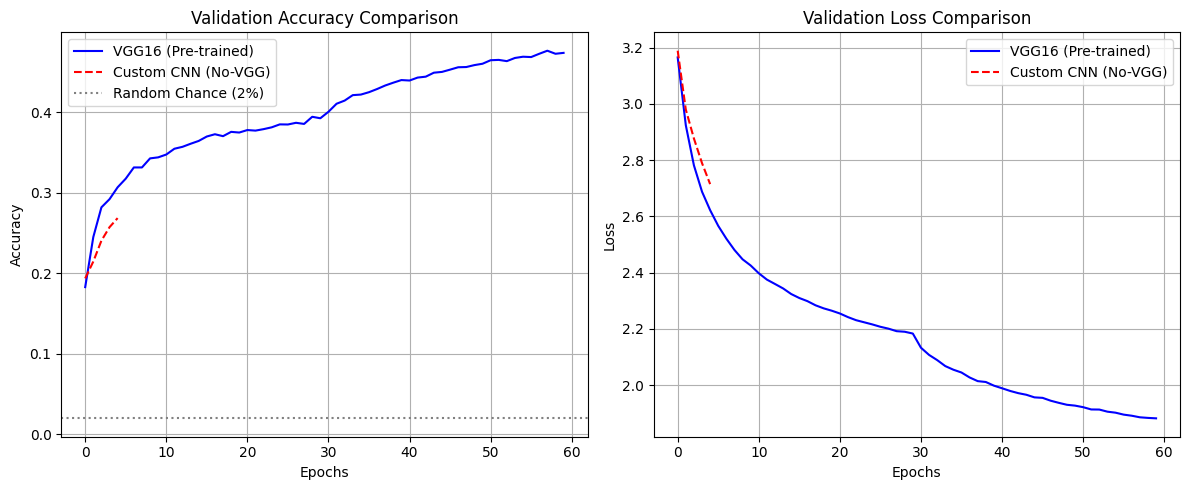

In [3]:
val_generator.reset()
y_pred_probs = vgg_model.predict(val_generator)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

original_acc = np.mean(y_pred_labels == y_true)
y_scrambled = np.random.permutation(y_true)
scrambled_acc = np.mean(y_pred_labels == y_scrambled)

print("\n=== Validation Results ===")
print(f"VGG Original Accuracy: {original_acc:.4f}")
print(f"VGG Scrambled Accuracy: {scrambled_acc:.4f}")

vgg_val_acc = history_vgg_initial.history['val_accuracy'] + history_vgg_finetune.history['val_accuracy']
vgg_val_loss = history_vgg_initial.history['val_loss'] + history_vgg_finetune.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(vgg_val_acc, label='VGG16 (Pre-trained)', color='blue')
plt.plot(history_no_vgg.history['val_accuracy'], label='Custom CNN (No-VGG)', color='red', linestyle='--')
plt.axhline(y=0.02, color='gray', linestyle=':', label='Random Chance (2%)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(vgg_val_loss, label='VGG16 (Pre-trained)', color='blue')
plt.plot(history_no_vgg.history['val_loss'], label='Custom CNN (No-VGG)', color='red', linestyle='--')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow.keras.utils import img_to_array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        vgg16_base = model.get_layer('vgg16')

        feature_extractor_model = tf.keras.Model(
            inputs=vgg16_base.input,
            outputs=vgg16_base.get_layer(last_conv_layer_name).output
        )

        features = feature_extractor_model(img_tensor)
        tape.watch(features)

        x = features
        for layer in model.layers[model.layers.index(vgg16_base) + 1:]:
            x = layer(x)

        preds = x
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, features)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = features[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    # return the number between 0-1 close to 1 mean red(focus), close to 0 mean blue(noise)
    return heatmap.numpy()

def get_top5_from_averaged_preds(avg_preds, label_map):
    top_indices = np.argsort(avg_preds)[-5:][::-1]
    top5_labels = [label_map[i] for i in top_indices]
    top5_confidences = [avg_preds[i] for i in top_indices]
    return top5_labels, top5_confidences

def run_universal_art_analysis(image_paths, model, label_map, layer_name):
    num_images = len(image_paths)
    if num_images == 0:
        return

    fig, axes = plt.subplots(num_images, 2, figsize=(16, 6 * num_images))
    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, path in enumerate(image_paths):
        if not os.path.exists(path):
            continue

        filename = os.path.basename(path)
        img = Image.open(path).convert("RGB")
        w, h = img.size
        mid_w, mid_h = w // 2, h // 2
        quadrants = [
            img.crop((0, 0, mid_w, mid_h)),
            img.crop((mid_w, 0, w, mid_h)),
            img.crop((0, mid_h, mid_w, h)),
            img.crop((mid_w, mid_h, w, h))
        ]

        quad_superimposed = []
        preds_list = []

        for quad in quadrants:
            quad_resized = quad.resize((128, 128))
            img_array = img_to_array(quad_resized) / 255.0
            img_array_input = np.expand_dims(img_array, axis=0)

            preds_list.append(model.predict(img_array_input, verbose=0)[0])

            heatmap = make_gradcam_heatmap(img_array_input, model, layer_name)
            heatmap_resized = cv2.resize(heatmap, (128, 128))
            heatmap_cv2 = np.uint8(255 * heatmap_resized)

            # show the color on the map
            heatmap_color = cv2.applyColorMap(heatmap_cv2, cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

            superimposed = heatmap_color / 255.0 * 0.4 + img_array
            superimposed = superimposed / np.max(superimposed)
            quad_superimposed.append(superimposed)

        avg_preds = np.mean(preds_list, axis=0)
        labels, confs = get_top5_from_averaged_preds(avg_preds, label_map)

        predicted_artist = labels[0]
        top_confidence = confs[0]

        top_row = np.hstack((quad_superimposed[0], quad_superimposed[1]))
        bottom_row = np.hstack((quad_superimposed[2], quad_superimposed[3]))
        stitched_heatmap_img = np.vstack((top_row, bottom_row))

        ax_conf = axes[i, 0]
        y_pos = np.arange(len(labels))
        bars = ax_conf.barh(y_pos, confs, align='center', color=['#4e79a7'] + ['#bab0ac'] * 4)
        ax_conf.set_yticks(y_pos)
        ax_conf.set_yticklabels(labels)
        ax_conf.invert_yaxis()
        ax_conf.set_xlabel('Average Confidence Score (4 Tiles)')

        ax_conf.set_title(f'File: {filename}\nPredicted: {predicted_artist} ({top_confidence*100:.1f}%)', fontsize=14, fontweight='bold')
        ax_conf.set_xlim(0, 1.0)
        for bar, conf in zip(bars, confs):
            ax_conf.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{conf:.3f}', va='center')

        ax_cam = axes[i, 1]
        ax_cam.imshow(stitched_heatmap_img)
        ax_cam.set_title(f'Grad-CAM Analysis', fontsize=12)
        ax_cam.axis('off')

    plt.tight_layout()
    plt.savefig('universal_art_analysis_results.png')
    plt.show()

In [5]:
test_images = [
    'van_ai_c.png',
    'van_ai_nc.png',
    'joan_miro_ai.png',
    'dvc_ai.png',
    'pcs_ai.png'
]

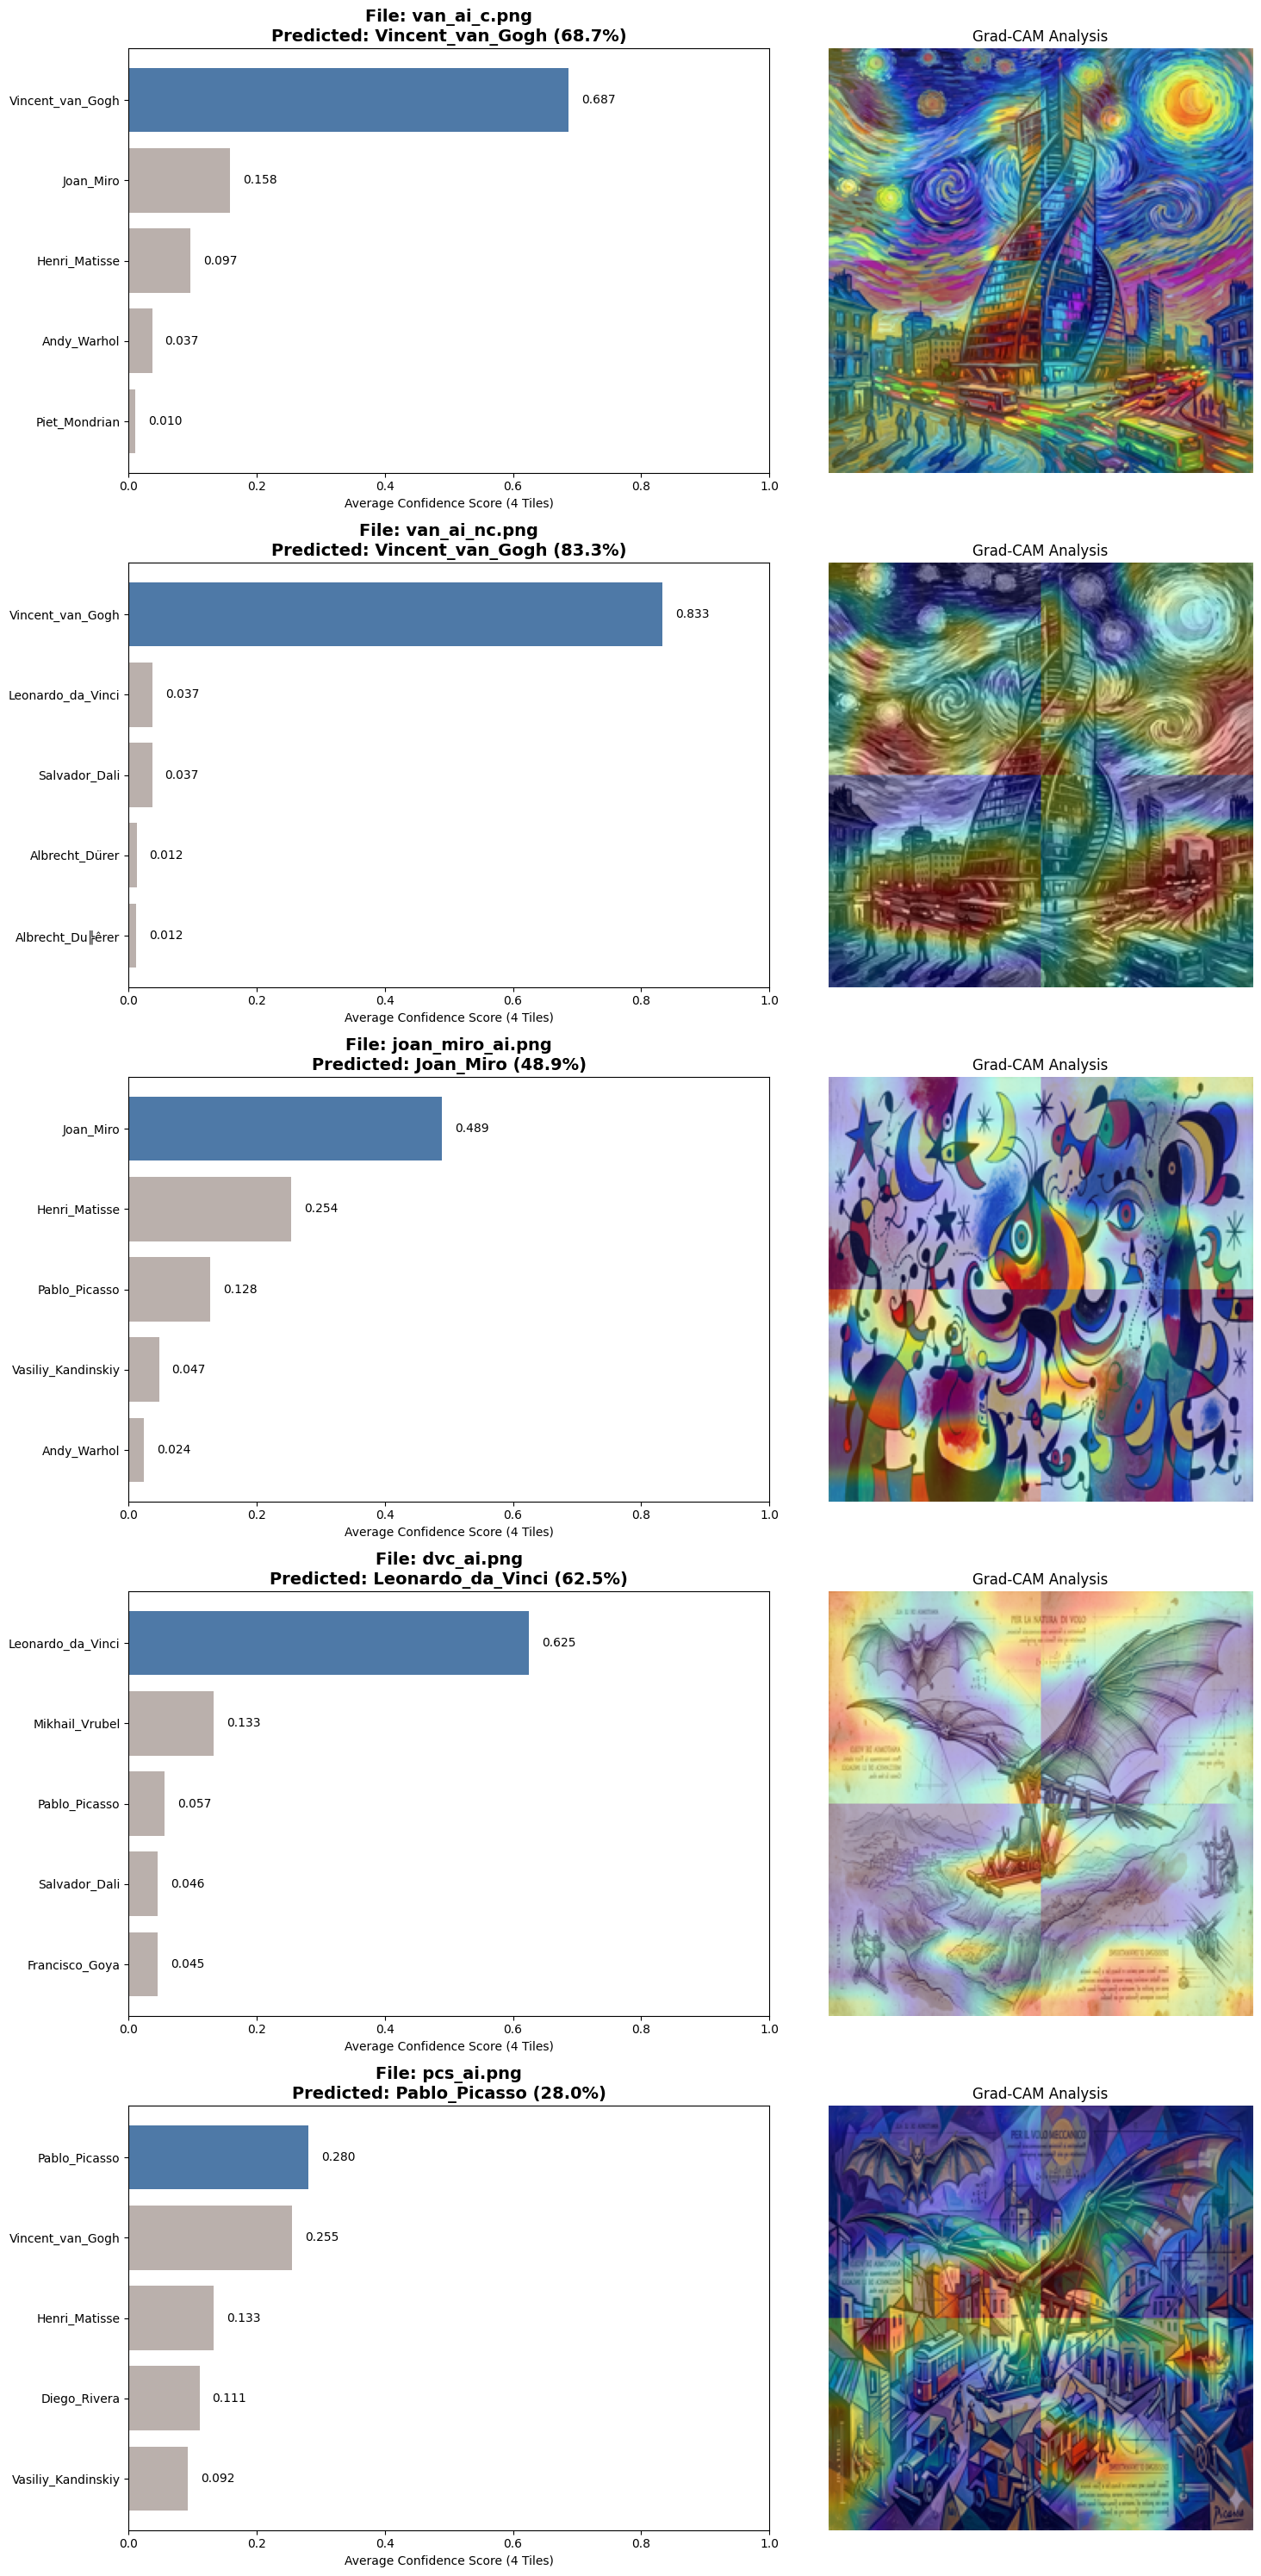

In [7]:
LAST_CONV_LAYER = 'block5_conv3'

# Create label_map from train_generator.class_indices
label_map = {v: k for k, v in train_generator.class_indices.items()}

run_universal_art_analysis(
    image_paths=test_images,
    model=vgg_model,
    label_map=label_map,
    layer_name=LAST_CONV_LAYER
)